# Processing the scRNAseq data
SCENIC+ demo.
https://scenicplus.readthedocs.io/en/latest/human_cerebellum_scRNA_pp.html

In [1]:
%%time
import scanpy as sc
data_dir = "/.mounts/labs/pailab/private/spai/data/SCENICp"

In [3]:
import os

In [4]:
adata = sc.read_10x_mtx(
    os.path.join(data_dir, "data/filtered_feature_bc_matrix/"),
    var_names = "gene_symbols"
)

In [5]:
adata.var_names_make_unique()

In [6]:
adata


AnnData object with n_obs × n_vars = 3233 × 36601
    var: 'gene_ids', 'feature_types'

In [7]:
import pandas as pd
cell_data = pd.read_table(os.path.join(data_dir,"data/cell_data.tsv"), index_col = 0)
cell_data

,VSN_cell_type,VSN_leiden_res0.3,VSN_leiden_res0.6,VSN_leiden_res0.9,VSN_leiden_res1.2,VSN_sample_id,Seurat_leiden_res0.6,Seurat_leiden_res1.2,Seurat_cell_type
AAACAGCCATTATGCG-1-10x_multiome_brain,MOL_B,MOL_B (0),MOL_B_1 (0),MOL_B_1 (1),MOL_B_3 (6),10x_multiome_brain,NFOL (1),MOL (1),MOL
AAACCAACATAGACCC-1-10x_multiome_brain,MOL_B,MOL_B (0),MOL_B_1 (0),MOL_B_3 (5),MOL_B_4 (4),10x_multiome_brain,NFOL (1),NFOL (3),NFOL
AAACCGAAGATGCCTG-1-10x_multiome_brain,INH_VIP,INH_VIP (6),INH_VIP (8),INH_VIP (8),INH_VIP (10),10x_multiome_brain,INH_VIP (7),INH_VIP (6),INH_VIP
AAACCGAAGTTAGCTA-1-10x_multiome_brain,MOL_A,MOL_A (1),MOL_A_2 (1),MOL_A_1 (0),MOL_A_2 (0),10x_multiome_brain,NFOL (1),NFOL (3),NFOL
AAACCGCGTTAGCCAA-1-10x_multiome_brain,MGL,MGL (7),MGL (10),MGL (10),MGL (12),10x_multiome_brain,MGL (8),MGL (9),MGL
...,...,...,...,...,...,...,...,...,...
TTTGTGAAGGGTGAGT-1-10x_multiome_brain,INH_VIP,INH_VIP (6),INH_VIP (8),INH_VIP (8),INH_VIP (10),10x_multiome_brain,INH_SST (5),INH_SST (8),INH_SST
TTTGTGAAGTCAGGCC-1-10x_multiome_brain,AST_CER,AST_CER (2),AST_CER (2),AST_CER (2),AST_CER_1 (7),10x_multiome_brain,BG (2),BG (2),BG
TTTGTGGCATGCTTAG-1-10x_multiome_brain,MOL_B,MOL_B (0),MOL_B_1 (0),MOL_B_1 (1),MOL_B_1 (1),10x_multiome_brain,MOL (0),MOL (1),MOL
TTTGTTGGTGATCAGC-1-10x_multiome_brain,MOL_A,MOL_A (1),MOL_A_2 (1),MOL_A_1 (0),MOL_A_1 (11),10x_multiome_brain,NFOL (1),NFOL (3),NFOL


In [8]:
cell_data.index = [cb.rsplit("-", 1)[0] for cb in cell_data.index]


In [9]:
adata = adata[list(set(adata.obs_names) & set(cell_data.index))].copy()


In [10]:
adata.obs = cell_data.loc[adata.obs_names]


In [11]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)

## Data normalization
It’s important to save the **non normalized** and **non scaled matrix** in the raw slot!

In [12]:
%%time
adata.raw = adata
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata = adata[:, adata.var.highly_variable]
sc.pp.scale(adata, max_value=10)

/u/spai/.conda/envs/scenicplus/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Revieved a view of an AnnData. Making a copy.
  view_to_actual(adata)


CPU times: user 3.1 s, sys: 314 ms, total: 3.41 s
Wall time: 8.02 s


In [13]:
adata.obs


,VSN_cell_type,VSN_leiden_res0.3,VSN_leiden_res0.6,VSN_leiden_res0.9,VSN_leiden_res1.2,VSN_sample_id,Seurat_leiden_res0.6,Seurat_leiden_res1.2,Seurat_cell_type,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt
CTATTACTCCTAAGGT-1,OPC,OPC (3),OPC (4),OPC (4),OPC (3),10x_multiome_brain,OPC (3),OPC (4),OPC,3178,8438.0,3.0,0.035553
AACAAAGGTCACGAAC-1,AST_CER,AST_CER (2),AST_CER (2),AST_CER (2),AST_CER_2 (5),10x_multiome_brain,BG (2),BG (2),BG,2331,4619.0,1.0,0.021650
TAGTTGTCATGAAATG-1,INH_VIP,INH_VIP (6),INH_VIP (8),INH_VIP (8),INH_VIP (10),10x_multiome_brain,INH_VIP (7),INH_VIP (6),INH_VIP,6201,23063.0,7.0,0.030352
CCAACATAGGAACCAA-1,GC,GC (4),GC (5),GC (6),GC (8),10x_multiome_brain,GC (4),GC (5),GC,6244,24173.0,79.0,0.326811
AGTTACATCCCATAGG-1,MOL_B,MOL_B (0),MOL_B_1 (0),MOL_B_3 (5),MOL_B_4 (4),10x_multiome_brain,NFOL (1),NFOL (3),NFOL,2085,5483.0,3.0,0.054715
...,...,...,...,...,...,...,...,...,...,...,...,...,...
GTAAGCTTCGGGATTT-1,MOL_A,MOL_A (1),MOL_A_2 (1),MOL_A_1 (0),MOL_A_2 (0),10x_multiome_brain,MOL (0),MOL (0),MOL,1923,3863.0,8.0,0.207093
TGGTCCTTCAATGAGG-1,GP,GP (8),GP (11),GP (12),GP (14),10x_multiome_brain,GC (4),GC (5),GC,7383,37606.0,43.0,0.114343
GATGGCTGTTGGATAT-1,AST_CER,AST_CER (2),AST_CER (2),AST_CER (2),AST_CER_2 (5),10x_multiome_brain,BG (2),BG (2),BG,1706,2887.0,5.0,0.173190
TTTAAGCCAGTAATAG-1,MOL_B,MOL_B (0),MOL_B_1 (0),MOL_B_1 (1),MOL_B_1 (1),10x_multiome_brain,NFOL (1),MOL (1),MOL,2201,6589.0,10.0,0.151768


/u/spai/.conda/envs/scenicplus/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


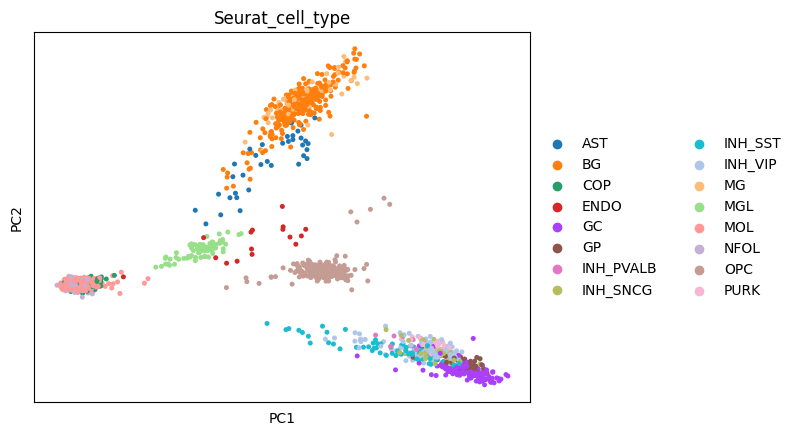

In [14]:
sc.tl.pca(adata)
sc.pl.pca(adata, color = "Seurat_cell_type")

In [15]:
sc.pp.neighbors(adata)


In [16]:
sc.tl.umap(adata)


/u/spai/.conda/envs/scenicplus/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


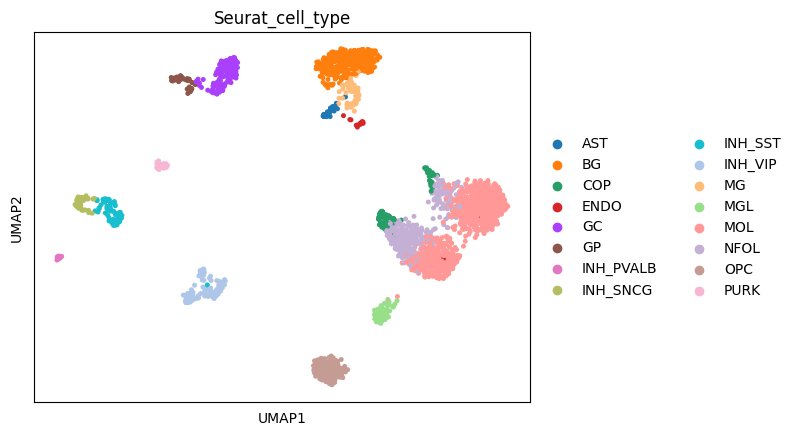

In [17]:
sc.pl.umap(adata, color = "Seurat_cell_type")

In [18]:
adata.write("adata.h5ad")
